# Problem Title - Dataset audit and target profile
Issue: #10

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
   

In [4]:
df = pd.read_csv('../dataset.csv')

In [5]:
df.shape

(1030, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1030 non-null   float64
 1   Blast Furnace Slag             1030 non-null   float64
 2   Fly Ash                        1030 non-null   float64
 3   Water                          1030 non-null   float64
 4   Superplasticizer               1030 non-null   float64
 5   Coarse Aggregate               1030 non-null   float64
 6   Fine Aggregate                 1030 non-null   float64
 7   Age                            1030 non-null   int64  
 8   Concrete compressive strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
df.isnull().sum()

Cement                           0
Blast Furnace Slag               0
Fly Ash                          0
Water                            0
Superplasticizer                 0
Coarse Aggregate                 0
Fine Aggregate                   0
Age                              0
Concrete compressive strength    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(25)

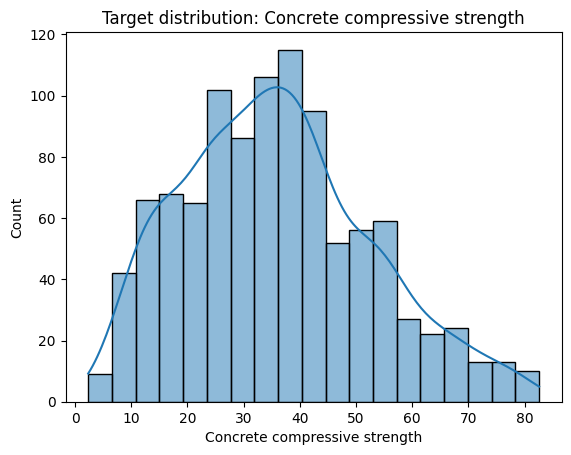

In [10]:
sns.histplot(df["Concrete compressive strength"], kde=True)
plt.title("Target distribution: Concrete compressive strength")
plt.xlabel("Concrete compressive strength")
plt.show()


In [11]:
skewness = df["Concrete compressive strength"].skew()
skewness

np.float64(0.416977288410718)

  
### Observations

1. The dataset contains 1030 rows and 9 columns, with all features being numeric (8 float64 and 1 int64).
2. No missing values are present, indicating good data completeness.
3. There are 25 duplicate rows (~2.43% of the dataset), which may require removal before modeling.
4. The target variable (Concrete compressive strength) has skewness = 0.45, indicating moderate positive skew.
5. Some input features (e.g., Fly Ash and Blast Furnace Slag) contain many zero values, indicating sparse usage in certain samples.

# Problem Title - Outlier and skewness analysis for all features
Issue: #9


In [12]:
features = df.select_dtypes(include=[np.number]).columns.tolist()

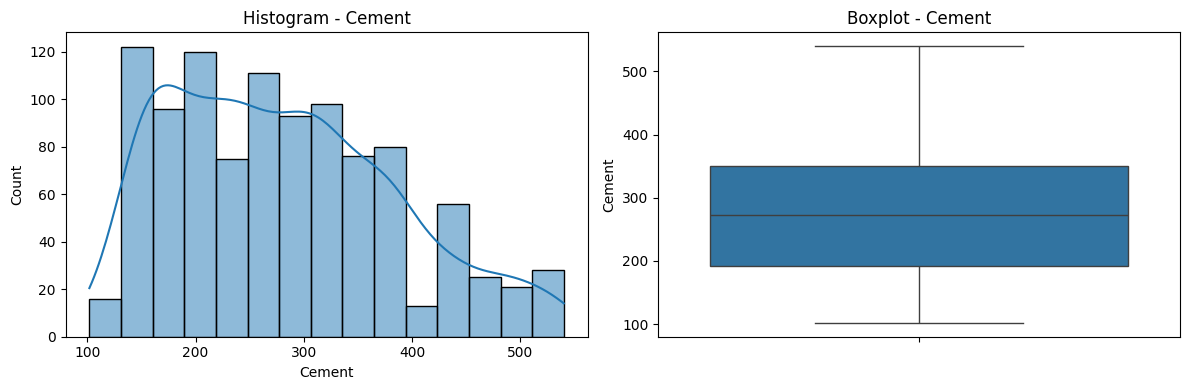

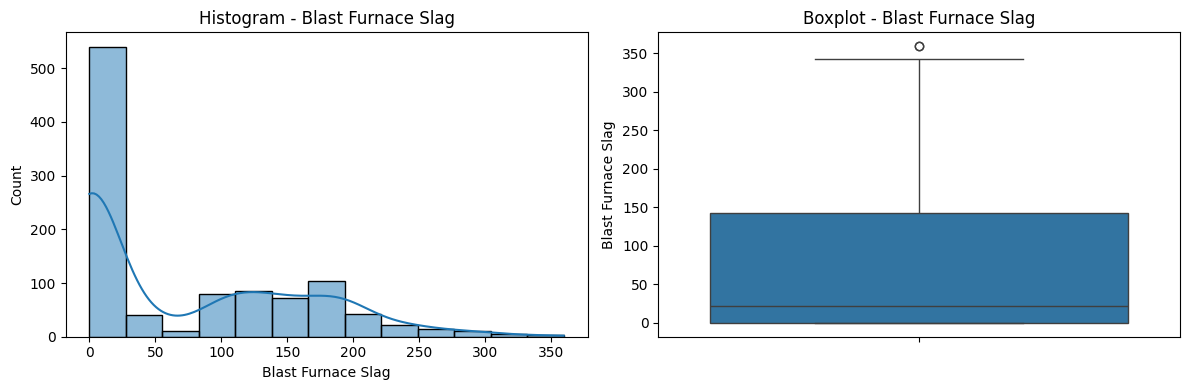

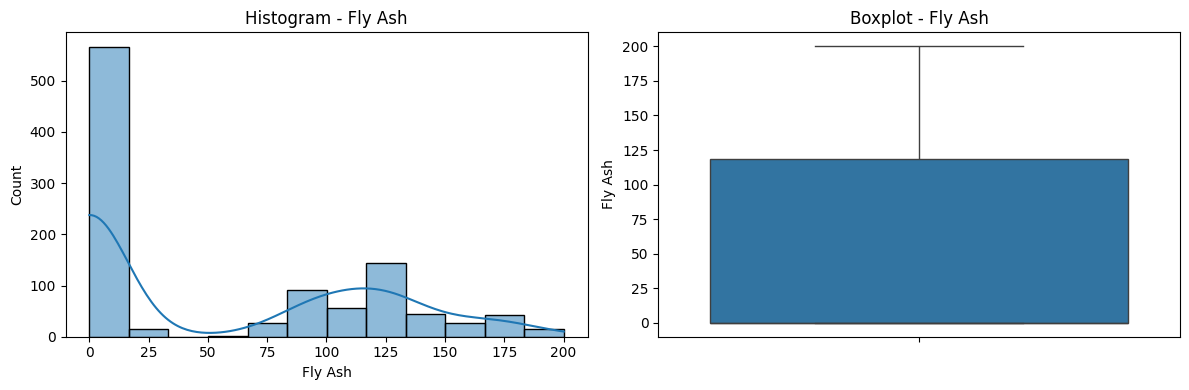

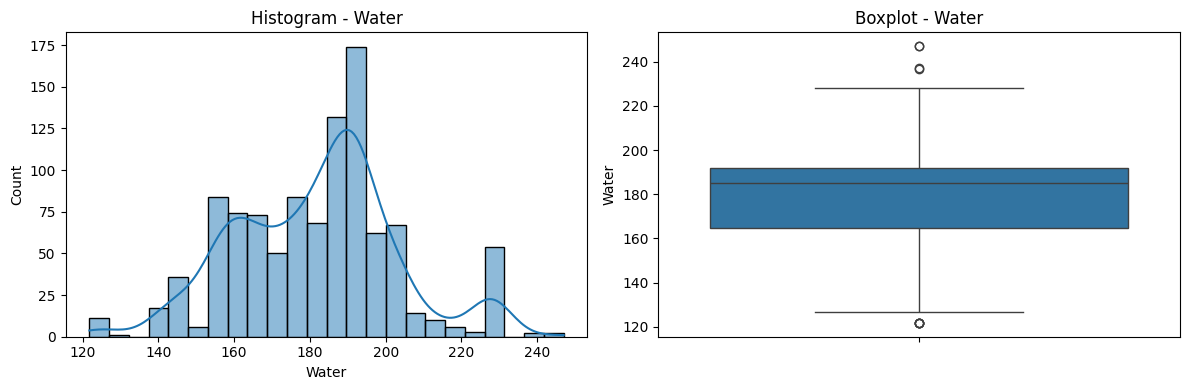

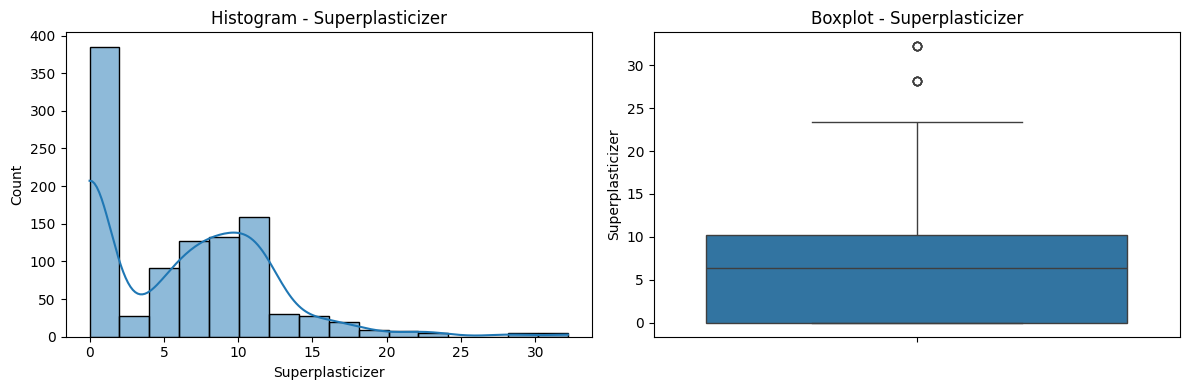

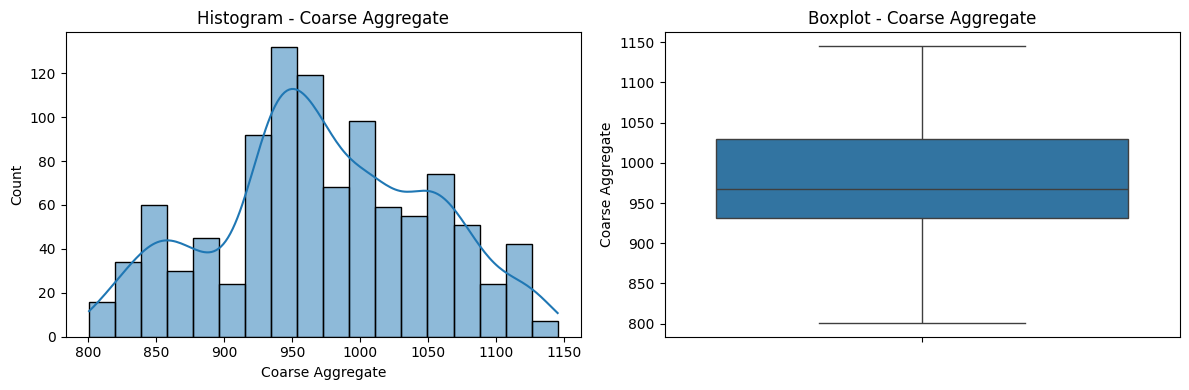

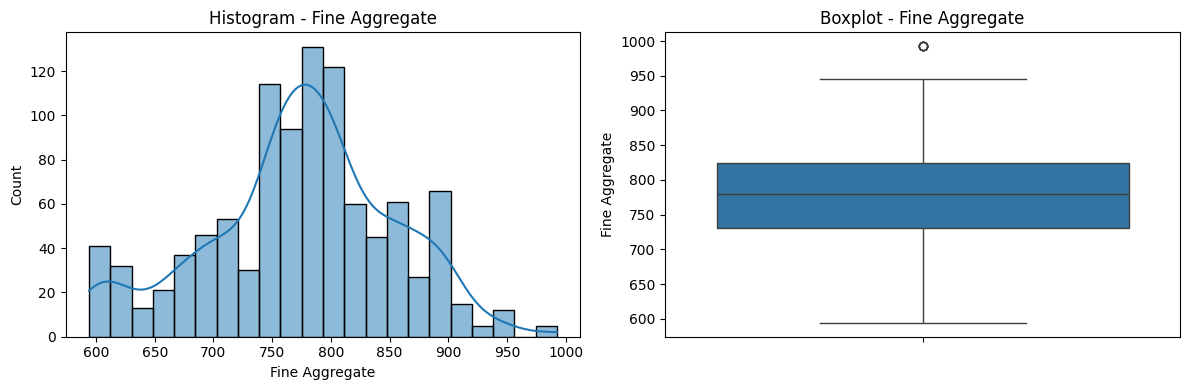

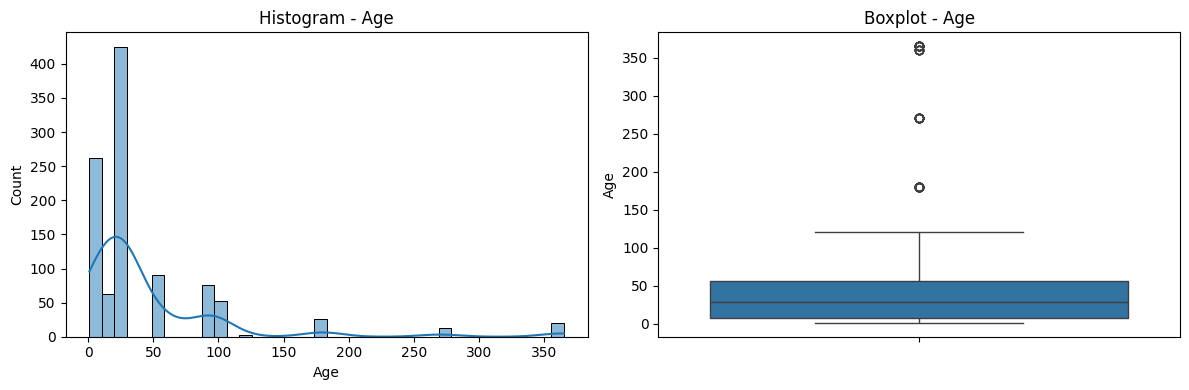

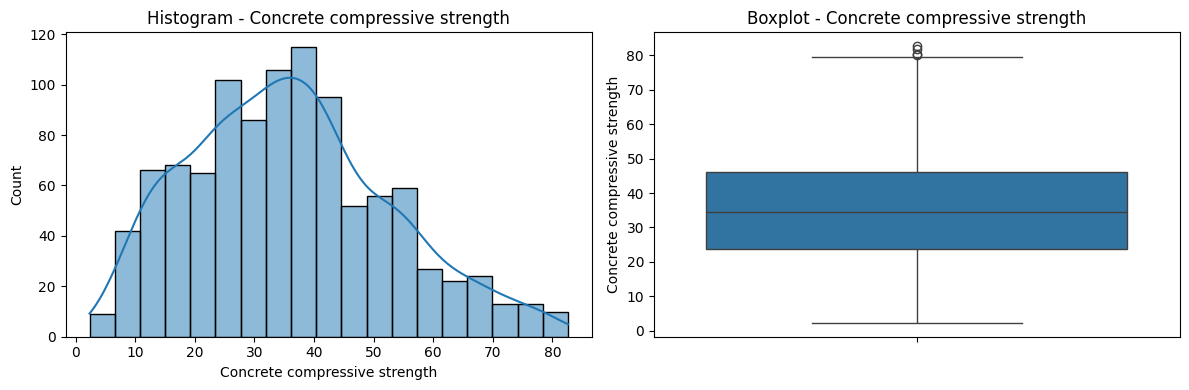

In [13]:
for col in features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], ax=axes[0], kde=True)
    axes[0].set_title(f'Histogram - {col}')
    sns.boxplot(y=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot - {col}')
    plt.tight_layout()
    plt.show()

In [14]:
skew_series = df[features].skew().abs().sort_values(ascending=False)
top3_skewed = skew_series.head(3)

outlier_counts = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outlier_counts[col] = len(outliers)

print( outlier_counts)
print(top3_skewed)

{'Cement': 0, 'Blast Furnace Slag': 2, 'Fly Ash': 0, 'Water': 9, 'Superplasticizer': 10, 'Coarse Aggregate': 0, 'Fine Aggregate': 5, 'Age': 59, 'Concrete compressive strength': 4}
Age                   3.269177
Superplasticizer      0.907203
Blast Furnace Slag    0.800717
dtype: float64


## Preprocessing

1. Log-transform highly skewed features (skew > 1)
2. Cap or remove IQR-based outliers in features with high outlier counts
3. Standardize/normalize features before model training
4. Impute or drop missing values if any, are found during exploration

# Problem Title - Feature-target relationship ranking
Issue : #8

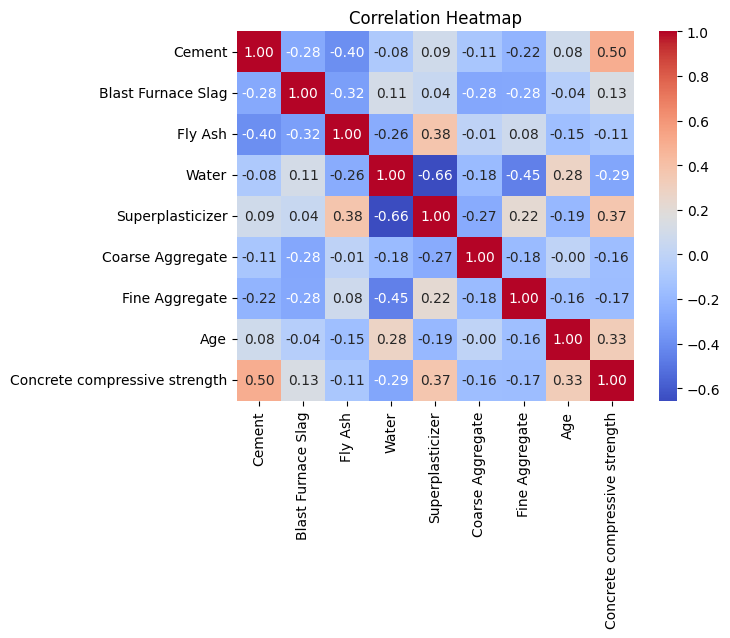

In [15]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()